# League Analysis

In [5]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

model_aliases = {
    "fixed_2p": "DQN Fixed",
    "variable_2_4": "DQN Variable",
    "variable_encoder_2_4": "DQN Variable + Encoder",
    "random": "Random",
    "deep_cfr_2p": "Deep CFR",
}
model_order = ["DQN Fixed", "DQN Variable", "DQN Variable + Encoder", "Deep CFR","Random"]

result_roots = [Path("results/2p_league_results"), Path("../../results/2p_league_results")]
results_root = next(path for path in result_roots if path.exists())

frames = []
player_count = 2
path = results_root / f"{player_count}p" / "matches.csv"
if not path.exists():
    print(f"Warning: {path} does not exist, skipping.")

data = pd.read_csv(path)
data["player_count"] = player_count
frames.append(data)

df = pd.concat(frames, ignore_index=True)
def split_pipe(value):
    return str(value).split("|")

def mean_pipe_ints(value):
    values = [int(part) for part in split_pipe(value)]
    return sum(values) / len(values)

df["competitor_label"] = df["competitor"].map(model_aliases)
df["opponent_labels"] = df["opponent_competitors"].apply(
    lambda names: [model_aliases[name] for name in split_pipe(names)]
)
df["opponent_mean_points"] = df["opponent_points_all"].apply(mean_pipe_ints)
df["point_margin"] = df["points"] - df["opponent_mean_points"]
df["won"] = df["outcome"].eq("win")
df["player_count_label"] = df["player_count"].astype(str) + "p"

## Results Loaded

In [6]:
loaded = (
    df.groupby("player_count")
      .agg(rows=("match_id", "size"), games=("match_id", "nunique"), matchups=("matchup_id", "nunique"))
      .reset_index()
)
loaded

,player_count,rows,games,matchups
0,2,20000,10000,10


## Overall Results

In [7]:
overall = (
    df.groupby(["player_count", "competitor_label"])
      .agg(
          games=("match_id", "size"),
          wins=("won", "sum"),
          losses=("outcome", lambda x: x.eq("loss").sum()),
          ties=("outcome", lambda x: x.eq("tie").sum()),
          raw_win_rate=("won", "mean"),
          mean_points=("points", "mean"),
          mean_margin=("point_margin", "mean"),
      )
      .reset_index()
)
overall.style.format({
    "raw_win_rate": "{:.1%}",
    "mean_points": "{:.2f}",
    "mean_margin": "{:+.2f}",
})

,player_count,competitor_label,games,wins,losses,ties,raw_win_rate,mean_points,mean_margin
0,2,DQN Fixed,4000,2147,1812,41,53.7%,56.44,+4.71
1,2,DQN Variable,4000,2105,1863,32,52.6%,56.19,+4.66
2,2,DQN Variable + Encoder,4000,2907,1052,41,72.7%,58.43,+8.78
3,2,Deep CFR,4000,2754,1201,45,68.8%,53.52,+7.38
4,2,Random,4000,7,3992,1,0.2%,38.28,-25.53


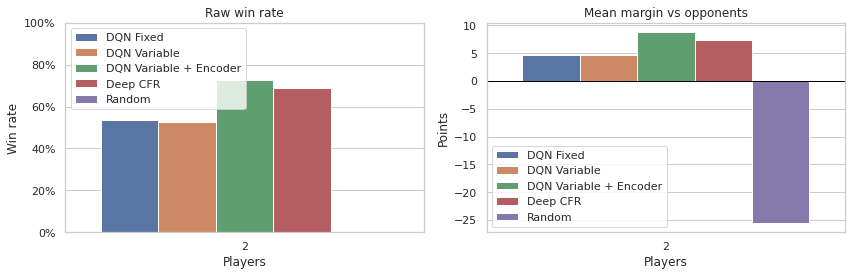

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.barplot(
    data=overall,
    x="player_count",
    y="raw_win_rate",
    hue="competitor_label",
    hue_order=model_order,
    errorbar=None,
    ax=axes[0],
)
axes[0].set_title("Raw win rate")
axes[0].set_xlabel("Players")
axes[0].set_ylabel("Win rate")
axes[0].set_ylim(0, 1)
axes[0].yaxis.set_major_formatter(lambda x, _: f"{x:.0%}")

sns.barplot(
    data=overall,
    x="player_count",
    y="mean_margin",
    hue="competitor_label",
    hue_order=model_order,
    errorbar=None,
    ax=axes[1],
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_title("Mean margin vs opponents")
axes[1].set_xlabel("Players")
axes[1].set_ylabel("Points")

for ax in axes:
    ax.legend(title="")
plt.tight_layout()

## Matchup View

In [9]:
opponent_rows = []
for row in df.itertuples(index=False):
    for opponent_label in row.opponent_labels:
        opponent_rows.append({
            "player_count": row.player_count,
            "competitor_label": row.competitor_label,
            "opponent_label": opponent_label,
            "won": row.won,
            "point_margin": row.point_margin,
        })

opponent_df = pd.DataFrame(opponent_rows)
matchup_summary = (
    opponent_df.groupby(["player_count", "competitor_label", "opponent_label"])
      .agg(
          rows=("won", "size"),
          raw_win_rate=("won", "mean"),
          mean_margin=("point_margin", "mean"),
      )
      .reset_index()
)
matchup_summary.style.format({
    "raw_win_rate": "{:.1%}",
    "mean_margin": "{:+.2f}",
})

,player_count,competitor_label,opponent_label,rows,raw_win_rate,mean_margin
0,2,DQN Fixed,DQN Variable,1000,51.0%,+0.18
1,2,DQN Fixed,DQN Variable + Encoder,1000,31.0%,-3.46
2,2,DQN Fixed,Deep CFR,1000,33.0%,-2.62
3,2,DQN Fixed,Random,1000,99.7%,+24.73
4,2,DQN Variable,DQN Fixed,1000,47.7%,-0.18
5,2,DQN Variable,DQN Variable + Encoder,1000,29.2%,-3.54
6,2,DQN Variable,Deep CFR,1000,33.8%,-2.59
7,2,DQN Variable,Random,1000,99.8%,+24.96
8,2,DQN Variable + Encoder,DQN Fixed,1000,67.9%,+3.46
9,2,DQN Variable + Encoder,DQN Variable,1000,69.7%,+3.54


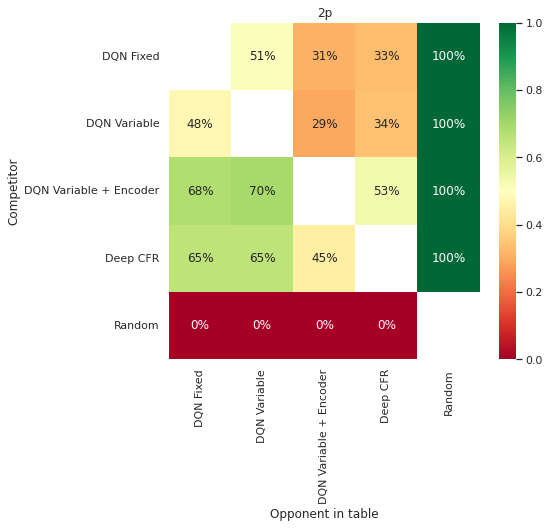

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8, 7.5)) 

matrix = matchup_summary[matchup_summary["player_count"] == 2].pivot(
    index="competitor_label", columns="opponent_label", values="raw_win_rate"
).reindex(index=model_order, columns=model_order)

sns.heatmap(matrix, annot=True, fmt=".0%", vmin=0, vmax=1, cmap="RdYlGn", ax=ax)

ax.set_title("2p")
ax.set_xlabel("Opponent in table")
ax.set_ylabel("Competitor")

plt.tight_layout()

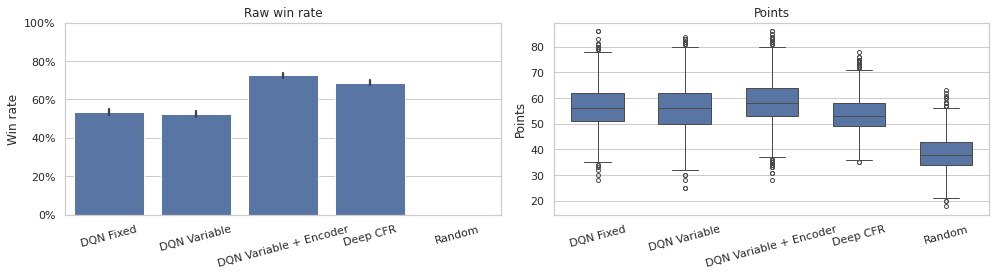

In [12]:
from matplotlib.ticker import PercentFormatter

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_color = sns.color_palette()[0]

sns.barplot(
    data=df, 
    x="competitor_label", 
    y="won", 
    order=model_order, 
    color=plot_color, 
    ax=axes[0]
)

axes[0].set_title("Raw win rate")
axes[0].set_ylabel("Win rate")
axes[0].set_xlabel("") 
axes[0].set_ylim(0, 1) 
axes[0].yaxis.set_major_formatter(PercentFormatter(1.0)) # Format Y-axis as 0%, 20%, etc.
axes[0].tick_params(axis='x', rotation=15)


sns.boxplot(
    data=df, 
    x="competitor_label", 
    y="points", 
    order=model_order, 
    color=plot_color, 
    ax=axes[1],
    width=0.6,   
    fliersize=4   
)

axes[1].set_title("Points")
axes[1].set_ylabel("Points")
axes[1].set_xlabel("") # Remove x-axis label
axes[1].tick_params(axis='x', rotation=15)

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show()